# Bayesian Model Selection in Cosmology: Evidence, Bayes Factors & Dark Energy


Today we ask one question over and over, in different clothes:

> *"Given the data, how much should I believe Model A versus Model B?"*

We will build up all the machinery to answer that question rigorously (Bayesian evidence, Bayes
factors, Savage–Dickey ratios, nested sampling, AIC/BIC, Occam's razor, model averaging), and then
put every single tool to work on a real, live scientific debate: **is dark energy just Einstein's
cosmological constant, or is it evolving with time?** This is exactly the question the *Dark Energy
Spectroscopic Instrument* (DESI) has been asking since 2024.

No prior cosmology background is assumed — the physics is introduced in plain language in Part 1,
and after that it is just numbers, likelihoods, and priors like any other statistics problem.

**How to use this notebook:** cells marked **"Your turn"** are exercises — you get a formula, a
template with a `# TODO`, and a hint. Try them yourself before your instructor reveals the
solution.


## Agenda

| # | Topic | Where |
|---|-------|-------|
| 1 | The physics, briefly: dark energy & its equation of state | Part 1 |
| 2 | Turning physics into a statistical model | Part 2 |
| 3 | **Your turn**: parameter estimation & MCMC | Part 3 |
| 4 | Bayesian evidence: definition & meaning | Part 4 |
| 5 | Nested sampling: the algorithm | Part 5 |
| 6 | Bayes factors & Jeffreys' scale | Part 6 |
| 7 | Savage–Dickey density ratio | Part 7 |
| 8 | Evidence vs. AIC/BIC | Part 8 |
| 9 | Occam's razor, automatically | Part 9 |
| 10 | **Your turn**: a third model, evidence table | Part 10 |
| 11 | Bayesian model averaging | Part 11 |
| 12 | Practical computation of evidences — cheat sheet | Part 12 |



## Setup

Standard scientific-Python packages, plus three specialists we'll meet along the way:
**`emcee`** (ensemble MCMC, Part 3), **`dynesty`** (nested sampling — the same family of
algorithm as `MultiNest` — Part 5 onward), and **`corner`** (posterior corner plots). All three
install with plain `pip`, which is why we use `dynesty` here rather than `MultiNest` itself
(which needs a Fortran/MPI compiler toolchain).


In [ ]:
# If running on Google Colab, uncomment the line below the first time you run this notebook.
!pip install dynesty corner emcee -q

import warnings
warnings.filterwarnings("ignore")  # dynesty/emcee are a little chatty about internal tuning; harmless here

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, optimize, stats

import emcee
import dynesty
from dynesty.utils import resample_equal
import corner

np.random.seed(42)   # reproducibility: same "random" mock data & sampler behaviour every time
plt.rcParams["figure.dpi"] = 110
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 2.2 MB/s eta 0:00:00
Setup complete.


## Part 1 — The physics, briefly

You do **not** need a cosmology background for this notebook. Here is everything you need, in five
bullet points:

- The universe's expansion is currently *accelerating*. Whatever is causing that acceleration is
  called **dark energy**. We don't know what it is — we only know its gravitational effect.
- We describe dark energy by how its pressure $p$ compares to its energy density $\rho$, through
  the **equation-of-state parameter** $w = p/\rho$.
  - If $w = -1$ exactly and never changes, dark energy behaves exactly like Einstein's
    **cosmological constant**, $\Lambda$. This is the "boring", simplest possibility, and it is the
    dark-energy sector of the standard cosmological model, **$\Lambda$CDM**.
  - If $w \neq -1$, or if $w$ *changes with redshift* $z$ (i.e. with cosmic time), dark energy is
    a *dynamical* substance rather than a constant — new physics.
- A common flexible way to let $w$ evolve is the **Chevallier–Polarski–Linder (CPL) parameterisation**:
$$ w(a) = w_0 + w_a(1-a), \qquad a = \frac{1}{1+z} $$
  Here $w_0$ is the value of $w$ today ($z=0$), and $w_a$ controls how fast it changes with time.
  Setting $w_0=-1, w_a=0$ recovers plain $\Lambda$CDM exactly — **$\Lambda$CDM is a special, nested
  case of the CPL model.** This nesting is precisely the structure Bayesian model comparison is
  built for.
- **DESI** is a spectroscopic survey that has measured the 3-D positions of tens of millions of
  galaxies and quasars. From the clustering of these objects it extracts **Baryon Acoustic
  Oscillation (BAO)** measurements: a "standard ruler" imprinted in the early universe, whose
  apparent size at different redshifts tells us the cosmic expansion history $H(z)$.
- Since 2024, DESI's own BAO results, especially when combined with cosmic-microwave-background
  and supernova data, have shown a mild-to-moderate preference for an evolving $w(z)$ over a
  constant $w=-1$ — one of the more talked-about results in cosmology right now. Today we will
  reproduce the *logic* of that kind of analysis (with simplified, synthetic data) using the full
  Bayesian model-selection toolkit.

**A important disclaimer before we start:** the "DESI-like" data below is **simulated**, generated
by us from a chosen "true" cosmology plus noise. It mimics the *redshifts* and *rough precision* of
real DESI BAO measurements so that the exercise feels realistic, but it is **not** the actual DESI
likelihood (which involves full covariance matrices, reconstruction algorithms, and cross-checks
we are deliberately skipping). Think of it as a flight simulator for the statistical method, not a
new cosmology result.


## Part 2 — Turning physics into a statistical model

We need a way to predict a distance from a proposed cosmology $(\Omega_m, w_0, w_a)$, so we can
compare it to (mock) data. Three formulas, and then we never look at the physics again:

$$ E(z) \equiv \frac{H(z)}{H_0} = \sqrt{\Omega_m(1+z)^3 + (1-\Omega_m)\,f_{\rm DE}(z)}, \qquad
f_{\rm DE}(z) = (1+z)^{3(1+w_0+w_a)}\, e^{-3 w_a z / (1+z)} $$

$$ D_C(z) = \frac{c}{H_0}\int_0^z \frac{dz'}{E(z')} \qquad \text{(comoving distance)}$$

$$ D_V(z) = \left[ (1+z)^2 D_A(z)^2 \, \frac{cz}{H(z)} \right]^{1/3}, \qquad D_A(z) = \frac{D_C(z)}{1+z} $$

$D_V(z)/r_d$ (distance divided by the sound-horizon scale $r_d$, essentially fixed) is the quantity
BAO surveys actually measure. **That is the last piece of physics you need** — from here on this
is pure statistics: we have a model that maps parameters $\theta$ to a predicted data vector, and
we have (mock) measurements with error bars. Every subsequent step is generic Bayesian machinery
that would look identical if $\theta$ were coin-flip probabilities or drug-trial effect sizes.

### Your turn — Exercise 1 (warm-up)

Complete the dark-energy density evolution factor $f_{\rm DE}(z)$ below. It's a direct
transcription of the formula above — the goal is just to make sure everyone is comfortable reading
a physics formula into code before we lean on `E_CPL` for everything else.

**Hint:** `f_DE(z) = (1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z))`. As a sanity check, when
`w0=-1` and `wa=0`, this must evaluate to `1.0` for *every* `z` (that's the plain-$\Lambda$CDM
limit — a constant dark-energy density).


In [ ]:
def f_DE(z, w0, wa):
    # Dark-energy density relative to today, as a function of redshift z.
    # Equals 1 (constant) for LCDM (w0=-1, wa=0); evolves otherwise.
    # TODO: implement the formula from the markdown cell above
    #raise NotImplementedError("Exercise 1: implement f_DE")
    return (1+z)**(3*(1+w0+wa)) * np.exp(-3*wa*z/(1+z))

# --- sanity check: do not edit below this line ---
z_test = np.array([0.0, 0.5, 1.0, 2.0])
check = f_DE(z_test, w0=-1.0, wa=0.0)
assert np.allclose(check, 1.0), f"For LCDM, f_DE should be 1 everywhere, got {check}"
print("f_DE passes the LCDM sanity check:", check)

f_DE passes the LCDM sanity check: [1. 1. 1. 1.]


Now the rest of the physics pipeline — fully worked, since it is not the point of today's
exercise. Read through it once so you trust what `DV_over_rd` is doing, then treat it as a black
box that answers: *"if the universe were described by these parameters, what distance would DESI
measure at this redshift?"*


In [ ]:
c  = 299792.458   # speed of light, km/s
H0 = 67.4         # Hubble constant, km/s/Mpc  -- FIXED (not fit) so that the model-comparison
                   #                                exercise below is purely about the dark-energy sector
rd = 147.09        # sound horizon at the drag epoch, Mpc -- also FIXED for the same reason

def E_CPL(z, Om, w0, wa):
    # E(z) = H(z)/H0 for a flat universe with matter Om and CPL dark energy (w0, wa).
    return np.sqrt(Om * (1 + z)**3 + (1 - Om) * f_DE(z, w0, wa))

def DV_over_rd(z, Om, w0, wa):
    # Predicted DESI-style BAO distance D_V(z)/r_d for a cosmology (Om, w0, wa).
    # z can be a single number or an array of redshifts.
    z = np.atleast_1d(z).astype(float)
    out = np.zeros_like(z)
    for i, zi in enumerate(z):
    # comoving distance = integral of 1/E(z') from 0 to zi
        DC = (c / H0) * integrate.quad(lambda zp: 1.0 / E_CPL(zp, Om, w0, wa), 0, zi)[0]
        DA = DC / (1 + zi)                     # angular diameter distance
        Hz = H0 * E_CPL(zi, Om, w0, wa)         # H(z)
        out[i] = ((1 + zi)**2 * DA**2 * c * zi / Hz)**(1/3) / rd   # volume-averaged distance, over r_d
    return out

print("D_V/r_d at z=1 for a fiducial LCDM cosmology:", DV_over_rd(1.0, 0.315, -1.0, 0.0))

D_V/r_d at z=1 for a fiducial LCDM cosmology: [20.82536321]


### Building a mock "DESI-like" dataset

We pick redshifts close to the effective redshifts of DESI's tracer classes (galaxies, quasars,
Lyman-$\alpha$ forest), a "true" cosmology with *mildly evolving* dark energy (inspired by, but not
identical to, the values reported in DESI's own DR2 analysis), and realistic-order-of-magnitude
percent-level noise.


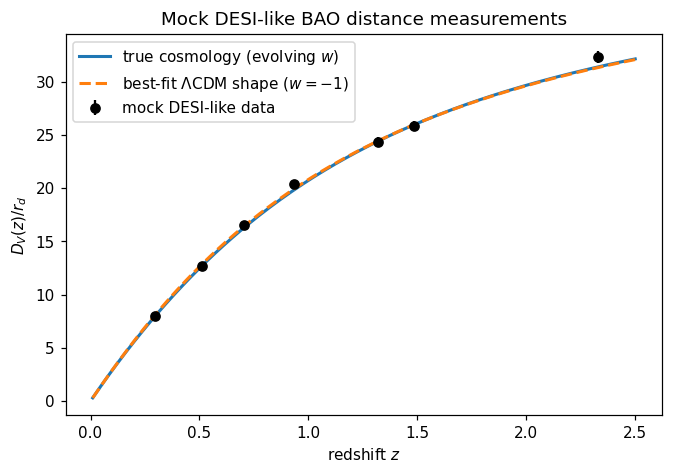

Data: [ 8.02 12.65 16.51 20.38 24.33 25.85 32.3 ]
Errors: [0.143 0.228 0.294 0.357 0.44  0.467 0.565]


In [ ]:
z_eff = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])   # ~ BGS, LRG1, LRG2, LRG3+ELG1, ELG2, QSO, Lya

# The "truth" we secretly used to generate the data -- in real life nobody gets to see this row!
Om_true, w0_true, wa_true = 0.315, -0.85, -0.60

data_true = DV_over_rd(z_eff, Om_true, w0_true, wa_true)     # noiseless prediction
frac_err  = 0.018                                             # ~1.8% per-point precision (BAO-alone, order of magnitude)
sigma     = frac_err * data_true
data_obs  = data_true + np.random.normal(0, sigma)            # add measurement noise -> this is our "data"

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(z_eff, data_obs, yerr=sigma, fmt="o", color="black", label="mock DESI-like data")
zgrid = np.linspace(0.01, 2.5, 200)
ax.plot(zgrid, DV_over_rd(zgrid, Om_true, w0_true, wa_true), label="true cosmology (evolving $w$)", lw=2)
ax.plot(zgrid, DV_over_rd(zgrid, Om_true, -1.0, 0.0), "--", label=r"best-fit $\Lambda$CDM shape ($w=-1$)", lw=2)
ax.set_xlabel("redshift $z$"); ax.set_ylabel(r"$D_V(z)/r_d$")
ax.legend(); ax.set_title("Mock DESI-like BAO distance measurements")
plt.show()

print("Data:", np.round(data_obs, 2))
print("Errors:", np.round(sigma, 3))

Notice the two curves are *close* — a few percent apart at most. That's the whole game: is
that few-percent difference something the data can actually distinguish from noise, or is it a
just-so story we're telling ourselves? Before we can ask *which model* is right (Part 4 onward),
we first need to ask, for a **fixed** model, what the data tell us about its parameters. That's
parameter estimation — our next stop.


### Likelihood and priors for our competing models

We define these once and reuse them for the rest of the notebook — first for MCMC parameter
estimation in Part 3, then for nested-sampling evidence calculations from Part 5 onward. Two models:

- **Model $M_0$ ($\Lambda$CDM):** 1 free parameter, $\Omega_m$. Dark energy fixed at $w=-1$.
- **Model $M_1$ (CPL / $w_0w_a$CDM):** 3 free parameters, $\Omega_m, w_0, w_a$.

Each model gets a **log-likelihood** (our Gaussian $\chi^2$), a **log-prior** (a prior *density*,
which is what MCMC wants), and a **prior transform** (the same prior expressed as a map from a
unit cube, which is what the nested sampler in Part 5 wants).


In [ ]:
# ---------- Model M0: Lambda-CDM (1 parameter: Om) ----------

def loglike_LCDM(theta):
    # Gaussian log-likelihood: -0.5 * chi^2, comparing the LCDM prediction to the mock data.
    Om = theta[0]
    model = DV_over_rd(z_eff, Om, -1.0, 0.0)     # w fixed at -1: no free dark-energy parameters
    return -0.5 * np.sum(((data_obs - model) / sigma)**2)

def log_prior_LCDM(theta):
    # Flat (uniform) prior Om ~ U(0.1, 0.5): log-density is 0 inside the range, -infinity outside.
    Om = theta[0]
    return 0.0 if 0.1 < Om < 0.5 else -np.inf

def ptform_LCDM(u):
    # The same prior, expressed as a unit-cube transform (the format dynesty wants -- see Part 5).
    return np.array([0.1 + 0.4 * u[0]])

# ---------- Model M1: CPL / w0waCDM (3 parameters: Om, w0, wa) ----------

def loglike_CPL(theta):
    # Gaussian log-likelihood for the full evolving-dark-energy model.
    Om, w0, wa = theta
    model = DV_over_rd(z_eff, Om, w0, wa)
    return -0.5 * np.sum(((data_obs - model) / sigma)**2)

def log_prior_CPL(theta):
    # Flat priors: Om ~ U(0.1,0.5), w0 ~ U(-2,0), wa ~ U(-3,2) -- typical, fairly wide ranges
    # used in the cosmology literature for these parameters.
    Om, w0, wa = theta
    if 0.1 < Om < 0.5 and -2.0 < w0 < 0.0 and -3.0 < wa < 2.0:
        return 0.0
    return -np.inf

def ptform_CPL(u):
    # The same priors, as a unit-cube transform for dynesty.
    Om = 0.1 + 0.4 * u[0]
    w0 = -2.0 + 2.0 * u[1]
    wa = -3.0 + 5.0 * u[2]
    return np.array([Om, w0, wa])

print("Model definitions ready: LCDM (1 param), CPL (3 params).")

Model definitions ready: LCDM (1 param), CPL (3 params).


## Part 3 — Parameter estimation & Markov Chain Monte Carlo (MCMC)

Fix one model $M$, and ask what the data tell us about its parameters $\theta$ — that's
**parameter estimation**:
$$ p(\theta \mid D, M) \;\propto\; \mathcal{L}(D \mid \theta, M)\, \pi(\theta \mid M) $$
Notice the normalising constant $Z(M)$ has vanished. We don't need it here, because parameter
estimation only ever compares the posterior at different values of $\theta$ *within the same
model* — and $Z$ cancels out of any such ratio. That observation is the whole idea behind
**Markov Chain Monte Carlo (MCMC)**: build a Markov chain whose stationary distribution *is* the
posterior, using only ratios of $\mathcal{L}\pi$. No integral required.

### The Metropolis–Hastings algorithm

1. Start somewhere, $\theta_0$.
2. **Propose** a new point $\theta' = \theta_{\rm current} + \epsilon$, with $\epsilon$ drawn from
   a symmetric distribution (e.g. a small Gaussian step).
3. Compute the acceptance ratio
   $$ \alpha = \min\left(1,\; \frac{\mathcal{L}(D\mid\theta')\,\pi(\theta')}{\mathcal{L}(D\mid\theta_{\rm current})\,\pi(\theta_{\rm current})}\right) $$
4. Draw $u \sim U(0,1)$. If $u < \alpha$, **accept**: move to $\theta'$. Otherwise **reject**: stay
   at $\theta_{\rm current}$ (and record it again — a rejection is still a valid chain step).
5. Repeat thousands of times. After discarding an initial **burn-in** — while the chain finds its
   way to the bulk of the posterior — the remaining samples are (correlated) draws from
   $p(\theta \mid D, M)$.

In log-space (safer numerically, and what we'll actually code), steps 3–4 become: accept if
$\ln u < \big[\ln\mathcal L(\theta') + \ln\pi(\theta')\big] - \big[\ln\mathcal L(\theta_{\rm current}) + \ln\pi(\theta_{\rm current})\big]$.

### Your turn — Exercise 2

Complete `accept_reject` below — it is literally steps 3–4 of the algorithm above, nothing more.

**Hint:** `log_alpha = logp_propose - logp_current`; accept if `np.log(np.random.rand()) < log_alpha`.
This is the log-space version of drawing $u \sim U(0,1)$ and accepting when $u < e^{\log\alpha}$ —
and it handles `log_alpha > 0` gracefully too (then $e^{\log\alpha} > 1$, so it always accepts).


Acceptance fraction: 0.47  (a healthy Metropolis-Hastings chain is usually ~20-50%)


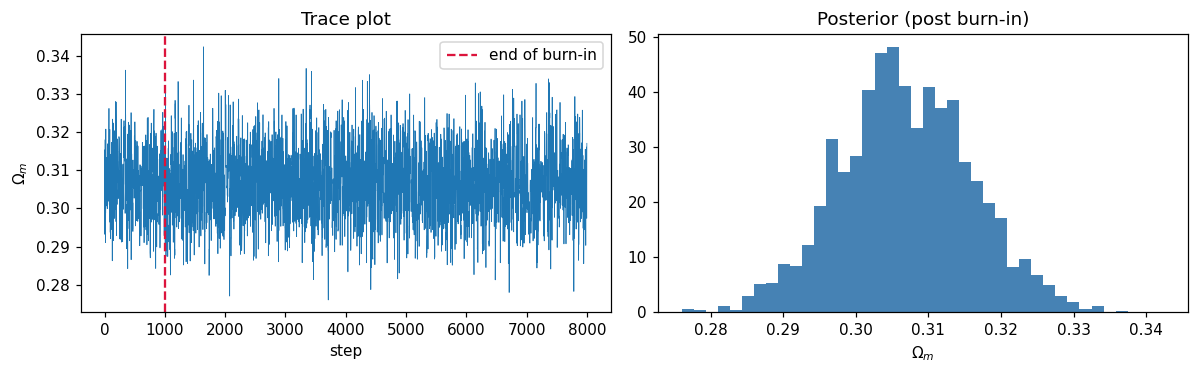

MCMC posterior: Om = 0.3069 +/- 0.0091


In [ ]:
def accept_reject(logp_current, logp_propose):
    # TODO (Exercise 2): return True if the proposed point should be accepted, False otherwise.
    #raise NotImplementedError("Exercise 2: implement accept_reject")
    log_alpha=logp_propose- logp_current
    return np.log(np.random.rand()) < log_alpha

def metropolis_hastings(log_post, theta0, step_size, n_steps):
    # A generic Metropolis-Hastings sampler. log_post is any function returning
    # log(likelihood) + log(prior) for a parameter vector theta.
    theta0 = np.atleast_1d(theta0).astype(float)
    chain = np.zeros((n_steps, len(theta0)))
    theta_current = theta0.copy()
    logp_current = log_post(theta_current)
    n_accept = 0
    for i in range(n_steps):
        theta_propose = theta_current + step_size * np.random.randn(len(theta0))
        logp_propose = log_post(theta_propose)
        if accept_reject(logp_current, logp_propose):
            theta_current, logp_current = theta_propose, logp_propose
            n_accept += 1
        chain[i] = theta_current
    return chain, n_accept / n_steps


def log_post_LCDM(theta):
    lp = log_prior_LCDM(theta)
    return lp + loglike_LCDM(theta) if np.isfinite(lp) else -np.inf

chain_LCDM, accept_frac = metropolis_hastings(log_post_LCDM, theta0=[0.3], step_size=[0.02], n_steps=8000)
print(f"Acceptance fraction: {accept_frac:.2f}  (a healthy Metropolis-Hastings chain is usually ~20-50%)")

burnin = 1000
samples_LCDM_mcmc = chain_LCDM[burnin:, 0]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(chain_LCDM[:, 0], lw=0.5)
axes[0].axvline(burnin, color="crimson", ls="--", label="end of burn-in")
axes[0].set_xlabel("step"); axes[0].set_ylabel(r"$\Omega_m$"); axes[0].set_title("Trace plot"); axes[0].legend()
axes[1].hist(samples_LCDM_mcmc, bins=40, density=True, color="steelblue")
axes[1].set_xlabel(r"$\Omega_m$"); axes[1].set_title("Posterior (post burn-in)")
plt.tight_layout()
plt.show()

print(f"MCMC posterior: Om = {samples_LCDM_mcmc.mean():.4f} +/- {samples_LCDM_mcmc.std():.4f}")

The trace plot (left) is the standard way to eyeball convergence: after burn-in it should
look like a "fuzzy caterpillar" wandering around a stable value, with no long-term drift. The
histogram (right) is your posterior — this is parameter estimation, exactly as promised, and it
needed no evidence and no nested sampling, only ratios of $\mathcal{L}\pi$.

### Scaling up: `emcee` and higher dimensions

Metropolis–Hastings worked nicely in 1-D. In higher dimensions, especially when parameters are
*correlated* (as $w_0$ and $w_a$ certainly are — watch for the tilted blob in the corner plot in
Part 5), a naive isotropic Gaussian proposal wastes most of its proposals on rejected moves, and
convergence slows painfully. **`emcee`** (Foreman-Mackey et al. 2013) is the standard practical fix
in astrophysics: it evolves many "walkers" together and proposes new points using the *current
spread of the other walkers*, automatically adapting to the shape of the posterior without you
hand-tuning a step size.


emcee mean acceptance fraction: 0.5050859375
emcee posterior means (Om, w0, wa): [ 0.27423298 -0.85302707 -0.38040794]


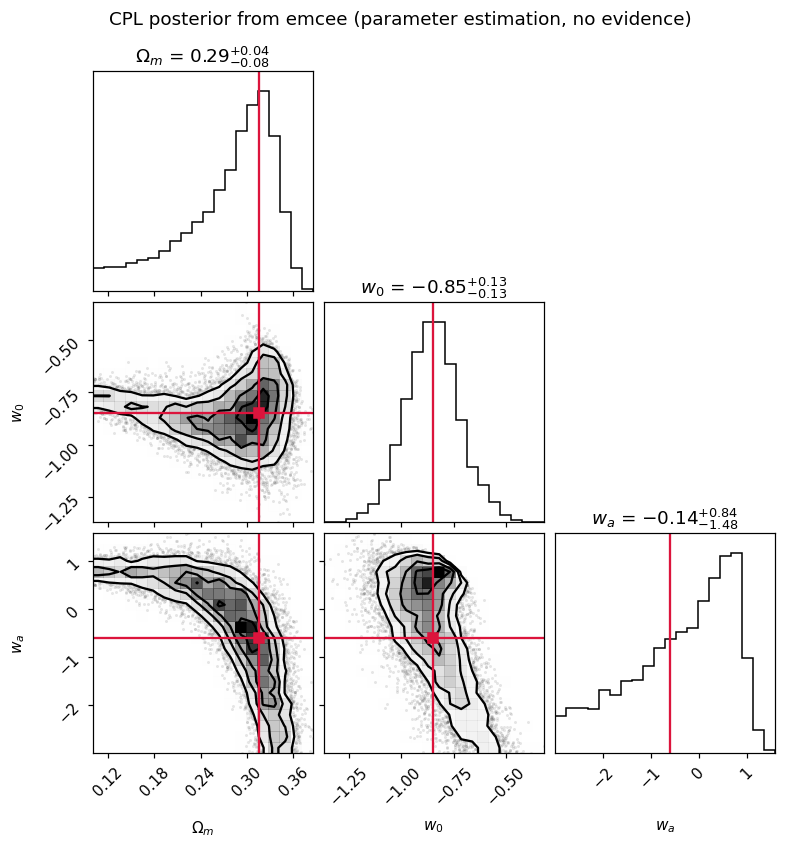

In [ ]:
def log_post_CPL(theta):
    lp = log_prior_CPL(theta)
    return lp + loglike_CPL(theta) if np.isfinite(lp) else -np.inf

ndim, nwalkers = 3, 32
p0_center = np.array([0.3, -1.0, 0.0])
p0 = p0_center + 1e-3 * np.random.randn(nwalkers, ndim)   # start all walkers in a tight ball

sampler_emcee = emcee.EnsembleSampler(nwalkers, ndim, log_post_CPL)
sampler_emcee.run_mcmc(p0, 4000, progress=False)

samples_CPL_mcmc = sampler_emcee.get_chain(discard=500, thin=10, flat=True)
print("emcee mean acceptance fraction:", sampler_emcee.acceptance_fraction.mean())
print("emcee posterior means (Om, w0, wa):", samples_CPL_mcmc.mean(axis=0))

fig = corner.corner(samples_CPL_mcmc, labels=[r"$\Omega_m$", r"$w_0$", r"$w_a$"],
                     truths=[Om_true, w0_true, wa_true], truth_color="crimson",
                     show_titles=True, title_fmt=".2f")
fig.suptitle("CPL posterior from emcee (parameter estimation, no evidence)", y=1.02)
plt.show()

### Your turn — Exercise 3

`emcee` (like our manual sampler) hands you a big pile of correlated samples — turning them into a
number you would report in a paper is itself part of parameter estimation. From `samples_CPL_mcmc`,
compute:

1. The posterior mean and standard deviation of $w_0$.
2. The **68% credible interval** for $w_0$ (the 16th and 84th percentiles — the Bayesian analogue
   of a "$1\sigma$ error bar").
3. Whether that interval includes $w_0 = -1$ (the $\Lambda$CDM value) — this is exactly the
   qualitative question a Bayes factor answers *quantitatively*, in Part 6.

**Hint:** `np.percentile(samples_CPL_mcmc[:, 1], [16, 50, 84])` gives the 16th/50th/84th
percentiles of the $w_0$ column in one call ($w_0$ is column index 1: `Om, w0, wa`).


In [ ]:
w0_mean = samples_CPL_mcmc[:, 1].mean()
w0_std = samples_CPL_mcmc[:, 1].std()
w0_16, w0_50, w0_84 = np.percentile(samples_CPL_mcmc[:, 1], [16, 50, 84]) # TODO: use np.percentile


# --- do not edit below; fill in the three lines above first ---
print(f"w0 = {w0_mean:.3f} +/- {w0_std:.3f}")
print(f"68% credible interval: [{w0_16:.3f}, {w0_84:.3f}]  (median {w0_50:.3f})")
includes_LCDM = w0_16 < -1.0 < w0_84
print(f"Does the 68% interval include w0 = -1 (LCDM)?  {includes_LCDM}")

w0 = -0.853 +/- 0.131
68% credible interval: [-0.981, -0.727]  (median -0.853)
Does the 68% interval include w0 = -1 (LCDM)?  False


### Why doesn't this give us $Z$?

Look back at step 3 of Metropolis–Hastings: the acceptance ratio only ever needs $\mathcal{L}\pi$
at *two points at a time* — the unknown normalising constant $Z$ never has to appear, because it
would cancel out of the ratio anyway. That is a genuine convenience for parameter estimation (one
less integral to worry about), but it means **plain MCMC is fundamentally blind to $Z$.** Getting
the evidence back needs different machinery entirely — which is exactly where nested sampling
comes in, next.


## Part 4 — Bayesian evidence: definition & meaning

For a model $M$ with parameters $\theta$, prior $\pi(\theta \mid M)$, and likelihood
$\mathcal{L}(D \mid \theta, M)$, Bayes' theorem for the *parameters* is

$$ p(\theta \mid D, M) = \frac{\mathcal{L}(D\mid\theta, M)\,\pi(\theta\mid M)}{Z(M)} $$

The normalising constant in the denominator,

$$ \boxed{\,Z(M) \equiv p(D \mid M) = \int \mathcal{L}(D \mid \theta, M)\, \pi(\theta \mid M)\, d\theta\,} $$

is the **Bayesian evidence** (also called the *marginal likelihood*). When you're only doing
parameter estimation *within* one model, $Z$ is just an annoying normalising constant you can
ignore. But $Z(M)$ is itself the probability of the *data*, averaged over the entire prior of the
model — and that makes it exactly the right quantity for comparing *models* via Bayes' theorem
applied one level up:

$$ \frac{p(M_1 \mid D)}{p(M_0 \mid D)} = \underbrace{\frac{Z(M_1)}{Z(M_0)}}_{\text{Bayes factor}} \times \frac{p(M_1)}{p(M_0)} $$

**In plain language:** $Z(M)$ answers *"averaged honestly over every parameter value my model
allows a priori, how well did I predict the data I actually saw?"* A model that fits beautifully
for a narrow sliver of its parameter space but poorly everywhere else gets penalised, because the
integral averages over the whole prior, not just the best-fit point. That is the seed of Occam's
razor, and we'll come back to it explicitly in Part 9.


## Part 5 — Nested sampling: the algorithm

The integral defining $Z$ is usually impossible in closed form once you have more than one or two
parameters. **Nested sampling** (Skilling, 2004) turns this hard, high-dimensional integral into an
easy 1-D one, by a clever change of variables.

Define the **prior volume enclosed above a likelihood threshold** $\lambda$:
$$ X(\lambda) = \int_{\mathcal{L}(\theta) > \lambda} \pi(\theta)\, d\theta $$
$X$ runs from $1$ (the whole prior, at $\lambda=0$) down to $0$ (only the very peak of the
likelihood). Because $X$ is monotonic in $\lambda$, we can invert it to get $\mathcal{L}(X)$, and
then the evidence becomes a simple 1-D integral over $X \in [0,1]$:
$$ Z = \int_0^1 \mathcal{L}(X)\, dX $$

**The algorithm**, in words:
1. Draw $N$ "live points" from the prior.
2. At every iteration, find and discard the live point with the **lowest** likelihood $\mathcal L_i$.
   Its current prior volume is estimated statistically as $X_i \approx e^{-i/N}$ (each discard
   shrinks the enclosed prior volume by a factor of roughly $(1 - 1/N)$, on average).
3. Replace the discarded point with a **new** point drawn from the prior, subject to the constraint
   that its likelihood must exceed $\mathcal L_i$. (This is the genuinely hard step — `MultiNest`
   does it via nested ellipsoidal bounds around the live points; `dynesty` offers several
   strategies: uniform sampling within ellipsoids, random walks, or slice sampling.)
4. Accumulate the evidence as a Riemann sum, $Z \approx \sum_i \mathcal{L}_i \, \Delta X_i$.
5. Stop once the remaining live points' contribution to $Z$ is negligible.

A very pleasant bonus: the discarded points, reweighted by $w_i \propto \mathcal{L}_i \Delta X_i$,
are automatically **posterior samples** — nested sampling gives you the evidence *and* the
posterior in one run, unlike plain MCMC (great for parameter estimation, but blind to $Z$).


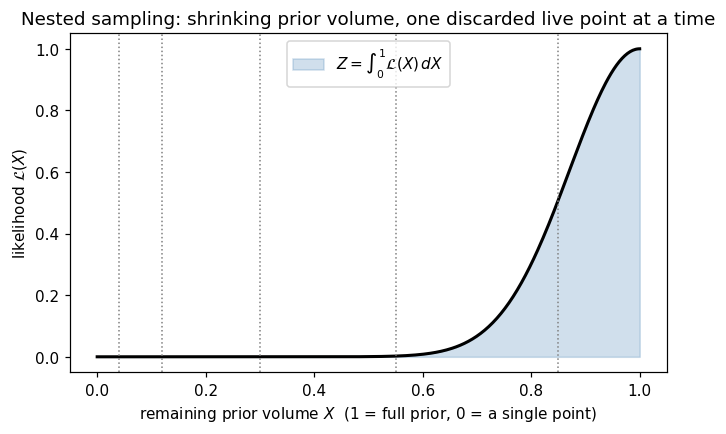

In [ ]:
# A schematic of the L(X) curve nested sampling integrates over -- purely illustrative, not real data.
X = np.linspace(1e-4, 1, 400)
L = np.exp(-30 * (1 - X)**2)   # a made-up likelihood shape: low across most of the prior, peaked near X=0

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(X, L, color="black", lw=2)
ax.fill_between(X, 0, L, alpha=0.25, color="steelblue", label=r"$Z = \int_0^1 \mathcal{L}(X)\,dX$")
for Xi in [0.85, 0.55, 0.30, 0.12, 0.04]:
    ax.axvline(Xi, color="gray", ls=":", lw=1)
ax.set_xlabel(r"remaining prior volume $X$  (1 = full prior, 0 = a single point)")
ax.set_ylabel(r"likelihood $\mathcal{L}(X)$")
ax.set_title("Nested sampling: shrinking prior volume, one discarded live point at a time")
ax.legend()
plt.show()

### Running nested sampling on our two cosmological models

We reuse exactly the `loglike_LCDM`, `ptform_LCDM`, `loglike_CPL`, `ptform_CPL` functions defined
back in Part 2 — nested sampling just needs the log-likelihood plus the prior expressed as a
unit-cube transform (rather than the log-density form MCMC wanted).


In [ ]:
print("Running nested sampling for LCDM (1 parameter)...")
sampler_LCDM = dynesty.NestedSampler(loglike_LCDM, ptform_LCDM, ndim=1, nlive=200)
sampler_LCDM.run_nested(print_progress=False)
res_LCDM = sampler_LCDM.results
logZ_LCDM, logZerr_LCDM = res_LCDM.logz[-1], res_LCDM.logzerr[-1]
print(f"  log Z (LCDM) = {logZ_LCDM:.3f} +/- {logZerr_LCDM:.3f}")

print("Running nested sampling for CPL (3 parameters)...")
sampler_CPL = dynesty.NestedSampler(loglike_CPL, ptform_CPL, ndim=3, nlive=300)
sampler_CPL.run_nested(print_progress=False)
res_CPL = sampler_CPL.results
logZ_CPL, logZerr_CPL = res_CPL.logz[-1], res_CPL.logzerr[-1]
print(f"  log Z (CPL)  = {logZ_CPL:.3f} +/- {logZerr_CPL:.3f}")

# Equally-weighted posterior samples "for free" from the nested-sampling run:
samples_LCDM = resample_equal(res_LCDM.samples, np.exp(res_LCDM.logwt - res_LCDM.logz[-1]))
samples_CPL  = resample_equal(res_CPL.samples,  np.exp(res_CPL.logwt  - res_CPL.logz[-1]))
print("\nPosterior mean Om (LCDM):", samples_LCDM[:, 0].mean(), "+/-", samples_LCDM[:, 0].std())
print("Posterior means (Om, w0, wa) (CPL):", samples_CPL.mean(axis=0))

# Sanity check: does nested sampling's posterior agree with the Metropolis-Hastings posterior
# for the same model and data, from Part 3? It should -- they're estimating the same thing.
print(f"\n[cross-check] MCMC (Part 3)     Om = {samples_LCDM_mcmc.mean():.4f} +/- {samples_LCDM_mcmc.std():.4f}")
print(f"[cross-check] Nested sampling   Om = {samples_LCDM[:, 0].mean():.4f} +/- {samples_LCDM[:, 0].std():.4f}")

Running nested sampling for LCDM (1 parameter)...
  log Z (LCDM) = -4.817 +/- 0.147
Running nested sampling for CPL (3 parameters)...
  log Z (CPL)  = -7.083 +/- 0.191

Posterior mean Om (LCDM): 0.3065493937517552 +/- 0.008704493962591231
Posterior means (Om, w0, wa) (CPL): [ 0.27684794 -0.85443759 -0.41419846]

[cross-check] MCMC (Part 3)     Om = 0.3069 +/- 0.0091
[cross-check] Nested sampling   Om = 0.3065 +/- 0.0087


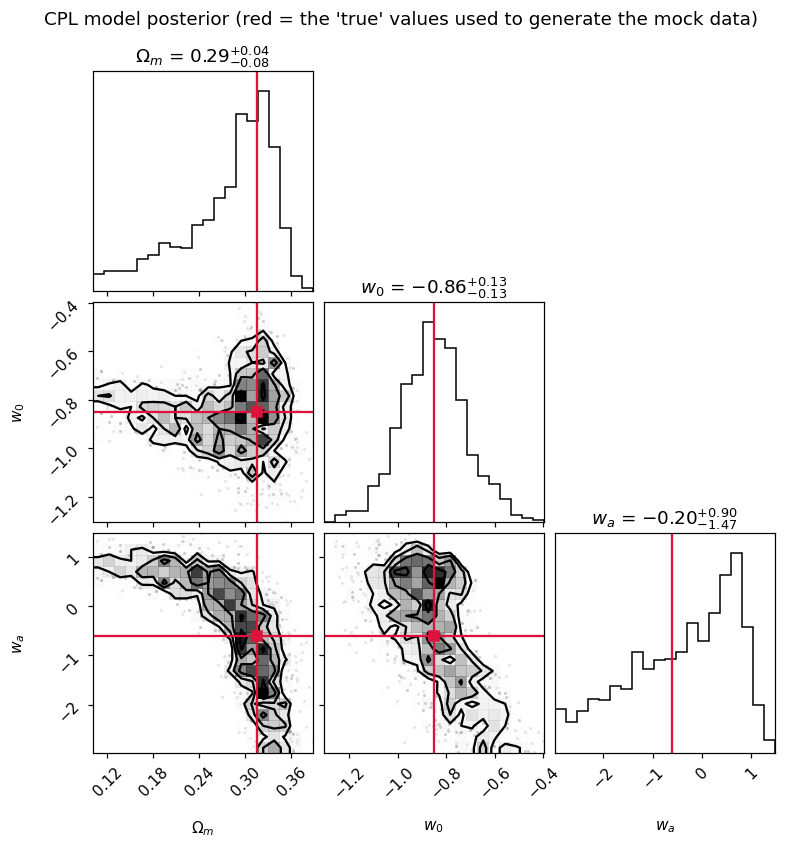

In [ ]:
fig = corner.corner(samples_CPL, labels=[r"$\Omega_m$", r"$w_0$", r"$w_a$"],
                     truths=[Om_true, w0_true, wa_true], truth_color="crimson",
                     show_titles=True, title_fmt=".2f")
fig.suptitle("CPL model posterior (red = the 'true' values used to generate the mock data)", y=1.02)
plt.show()

The red lines mark the cosmology we secretly used to generate the data. The posterior
*does* cover the true $(w_0, w_a)$ reasonably well — but it is also very broad, and it comfortably
includes the $\Lambda$CDM point $(w_0,w_a) = (-1, 0)$. With only 7 mock data points, the data alone
cannot pin down two extra parameters very precisely. Keep this picture in mind for Parts 7 and 9.

Also compare this shape to the `emcee` corner plot from Part 3: modulo Monte Carlo noise, two
completely independent algorithms should land on the same posterior. Nested sampling has
rediscovered it from scratch — and, as a bonus, also told us $\ln Z$.


## Part 6 — Bayes factors & Jeffreys' scale

The **Bayes factor** comparing model $M_1$ to model $M_0$ is simply the ratio of evidences,
$$ B_{10} = \frac{Z(M_1)}{Z(M_0)} $$
and (assuming we had no prior reason to favour either model, $p(M_1)=p(M_0)$) it *is* the posterior
odds between the two models. Because evidences can be extremely small numbers, we almost always
work with $\ln B_{10} = \ln Z_1 - \ln Z_0$.

How big does $|\ln B|$ need to be before you should actually change your mind? Harold Jeffreys
proposed a scale for this in 1961; the version most commonly used in cosmology today
(after Trotta 2008) is:

| $\vert \ln B_{10} \vert$ | Strength of evidence for the favoured model |
|---|---|
| $< 1.0$ | Inconclusive |
| $1.0 - 2.5$ | Weak evidence |
| $2.5 - 5.0$ | Moderate evidence |
| $> 5.0$ | Strong evidence |


In [ ]:
def interpret_bayes_factor(lnB):
    # Return a human-readable interpretation of a ln(Bayes factor) on Jeffreys' scale.
    # A positive lnB favours model 1; negative favours model 0.
    strength_bins = [(1.0, "Inconclusive"), (2.5, "Weak"), (5.0, "Moderate"), (np.inf, "Strong")]
    a = abs(lnB)
    for threshold, label in strength_bins:
        if a < threshold:
            strength = label
            break
    favoured = "model 1" if lnB > 0 else "model 0" if lnB < 0 else "neither model"
    return f"{strength} evidence in favour of {favoured} (|ln B| = {a:.2f})"

lnB_CPL_vs_LCDM = logZ_CPL - logZ_LCDM
print(f"ln B (CPL vs LCDM) = {lnB_CPL_vs_LCDM:.3f}   ->   B = {np.exp(lnB_CPL_vs_LCDM):.3f}")
print(interpret_bayes_factor(lnB_CPL_vs_LCDM).replace("model 1", "CPL").replace("model 0", "LCDM"))

ln B (CPL vs LCDM) = -2.266   ->   B = 0.104
Weak evidence in favour of LCDM (|ln B| = 2.27)


Run the cell above and read the number. With this particular mock dataset (7 points,
~1.8% precision — a *DESI-BAO-alone*-like precision) you should find the evidence mildly **favours
the simpler $\Lambda$CDM model**, even though we *know* the data was generated from an evolving-$w$
cosmology! This is not a bug — it is exactly the point of Part 9. Keep reading.

**A puzzle, if you did Exercise 3:** the MCMC 68% credible interval for $w_0$ probably *excluded*
$-1$ — so within the CPL model, $w_0=-1$ looked like a somewhat disfavoured value. Yet the Bayes
factor above still prefers $\Lambda$CDM overall. These are not contradictory — they are answering
different questions. A credible interval only describes the posterior's *shape within one model*;
it has no opinion on whether the extra parameters were worth their entry price in prior volume.
The Bayes factor is the one built to answer *that* question, and it is why "the fit improved" and
"the data support the more complex model" are not the same statement in Bayesian statistics.


## Part 7 — Savage–Dickey density ratio

Computing a full nested-sampling evidence for both models is powerful but expensive. When one
model is a **special case of the other** — exactly our situation, since $\Lambda$CDM is the CPL
model at the single point $(w_0, w_a) = (-1, 0)$ — there is a shortcut that needs *only* the
posterior samples of the *bigger* model.

**Savage–Dickey density ratio theorem:** if $M_0$ is $M_1$ with a sub-vector of parameters
$\phi$ fixed at $\phi_0$, and the priors agree ($\pi(\theta\mid M_0) = \pi(\theta \mid \phi=\phi_0, M_1)$
for the shared parameters), then
$$ B_{01} = \frac{Z(M_0)}{Z(M_1)} = \frac{p(\phi = \phi_0 \mid D, M_1)}{p(\phi=\phi_0 \mid M_1)} $$
i.e. the Bayes factor *for* the simpler model equals the ratio of the **posterior density** to the
**prior density**, both evaluated at the nested point, entirely within the bigger model's chain. No
second nested-sampling run required!

Intuition: if the data have pulled the posterior at $\phi_0$ to be *taller* than the flat prior was
there, that's evidence *for* the simpler model (the data are happy sitting at $\phi_0$); if the
posterior has emptied out around $\phi_0$, that's evidence *against* it.


In [ ]:
from scipy.stats import gaussian_kde

# Posterior density at the LCDM point (w0, wa) = (-1, 0), estimated from the CPL model's own chain
kde_w0wa = gaussian_kde(samples_CPL[:, 1:3].T)     # 2D kernel density estimate over (w0, wa) samples
posterior_density_at_null = kde_w0wa([-1.0, 0.0])[0]

# Prior density at that same point: our priors were uniform, w0 ~ U(-2,0), wa ~ U(-3,2)
prior_density_at_null = 1.0 / ((0.0 - (-2.0)) * (2.0 - (-3.0)))

B_LCDM_vs_CPL_SD = posterior_density_at_null / prior_density_at_null

print(f"Posterior density at (w0,wa)=(-1,0): {posterior_density_at_null:.3f}")
print(f"Prior density at that point:         {prior_density_at_null:.3f}")
print(f"Savage-Dickey B(LCDM vs CPL)  = {B_LCDM_vs_CPL_SD:.3f}")
print(f"Direct evidence ratio B(LCDM vs CPL) = {np.exp(-lnB_CPL_vs_LCDM):.3f}   <- from Part 6, for comparison")

Posterior density at (w0,wa)=(-1,0): 0.745
Prior density at that point:         0.100
Savage-Dickey B(LCDM vs CPL)  = 7.451
Direct evidence ratio B(LCDM vs CPL) = 9.638   <- from Part 6, for comparison


The two numbers won't match exactly (Savage–Dickey relies on a kernel density estimate,
which has its own noise, and our nested-sampling evidences carry their own Monte Carlo error too)
but they should agree in **order of magnitude and conclusion**. That agreement is a genuinely
useful cross-check to run in practice — if the full-evidence calculation and the Savage–Dickey
shortcut wildly disagree, something is wrong (mismatched priors are the classic culprit).


## Part 8 — Bayesian evidence vs. AIC/BIC

You've likely met the **Akaike** and **Bayesian Information Criteria** in a frequentist context:
$$ \mathrm{AIC} = 2k - 2\ln\mathcal{L}_{\max}, \qquad \mathrm{BIC} = k\ln n - 2\ln\mathcal{L}_{\max} $$
where $k$ is the number of free parameters, $n$ the number of data points, and $\mathcal{L}_{\max}$
the maximum likelihood achieved by the model. Lower AIC/BIC is preferred; a common rule of thumb
treats a difference $> 6-10$ as decisive.

**How do these relate to $\ln Z$?** BIC is what you get by taking $-2\ln Z$ and applying a rough,
large-sample (Laplace) approximation for the integral, under the assumption that the prior is
essentially flat over the region where the likelihood is large. Formally,
$$ -2\ln Z \approx \mathrm{BIC} + \mathcal{O}(1) $$
So **BIC is a cheap, approximate stand-in for the evidence** that requires no integration at all —
just the best fit and a parameter count. It gets the *penalty for extra parameters* roughly right,
but:
- it ignores the actual **prior width** (only the evidence integral penalises a parameter that is
  technically free but essentially unconstrained by *both* prior and data the way it should — BIC
  only counts *that a parameter exists*, not how much prior volume it wastes);
- it assumes the "large sample" regime, which 7 BAO points most certainly are not;
- unlike $\ln Z$, it carries no notion of its own uncertainty.

**AIC** comes from a different derivation entirely (minimising expected Kullback–Leibler
information loss, i.e. predictive accuracy) and generally penalises extra parameters *less*
harshly than BIC does. It is best thought of as a distinct, useful quantity in its own right rather
than as another evidence approximation.


In [ ]:
def neg_loglike_LCDM(theta): return -loglike_LCDM(theta)
def neg_loglike_CPL(theta):  return -loglike_CPL(theta)

# Best-fit (maximum-likelihood) point for each model, by direct numerical optimisation
opt_LCDM = optimize.minimize(neg_loglike_LCDM, x0=[0.3], bounds=[(0.1, 0.5)])
opt_CPL  = optimize.minimize(neg_loglike_CPL,  x0=[0.3, -1.0, 0.0], bounds=[(0.1, 0.5), (-2, 0), (-3, 2)])
lnLmax_LCDM, lnLmax_CPL = -opt_LCDM.fun, -opt_CPL.fun

n = len(z_eff)
k_LCDM, k_CPL = 1, 3
AIC_LCDM = 2*k_LCDM - 2*lnLmax_LCDM
AIC_CPL  = 2*k_CPL  - 2*lnLmax_CPL
BIC_LCDM = k_LCDM*np.log(n) - 2*lnLmax_LCDM
BIC_CPL  = k_CPL*np.log(n)  - 2*lnLmax_CPL

print(f"{'':12s}{'k':>4s}{'lnLmax':>10s}{'AIC':>10s}{'BIC':>10s}{'ln Z':>10s}")
print(f"{'LCDM':12s}{k_LCDM:4d}{lnLmax_LCDM:10.2f}{AIC_LCDM:10.2f}{BIC_LCDM:10.2f}{logZ_LCDM:10.2f}")
print(f"{'CPL':12s}{k_CPL:4d}{lnLmax_CPL:10.2f}{AIC_CPL:10.2f}{BIC_CPL:10.2f}{logZ_CPL:10.2f}")

print(f"\nDelta AIC (CPL - LCDM) = {AIC_CPL - AIC_LCDM:.2f}   (positive => AIC also prefers LCDM)")
print(f"Delta BIC (CPL - LCDM) = {BIC_CPL - BIC_LCDM:.2f}   (positive => BIC also prefers LCDM)")
print(f"-0.5*DeltaBIC (a proxy for ln B) = {-0.5*(BIC_CPL - BIC_LCDM):.2f}   vs. the real  ln B = {lnB_CPL_vs_LCDM:.2f}")

               k    lnLmax       AIC       BIC      ln Z
LCDM           1     -2.14      6.29      6.23     -4.82
CPL            3     -1.56      9.11      8.95     -7.08

Delta AIC (CPL - LCDM) = 2.82   (positive => AIC also prefers LCDM)
Delta BIC (CPL - LCDM) = 2.71   (positive => BIC also prefers LCDM)
-0.5*DeltaBIC (a proxy for ln B) = -1.36   vs. the real  ln B = -2.27


All three criteria — evidence, AIC, BIC — should agree on *which* model is preferred here.
But notice the last line: BIC's *proxy* for $\ln B$ and the real, fully-integrated $\ln B$ from
nested sampling are only roughly similar, not identical — a nice, concrete illustration of BIC
being an approximation, not the real thing.


## Part 9 — Occam's razor as *automatic* in Bayesian model selection

Split the evidence integral into two intuitive pieces:
$$ Z = \int \mathcal{L}(\theta)\,\pi(\theta)\,d\theta \;\approx\; \mathcal{L}_{\max} \times
\underbrace{\frac{\Delta\theta_{\rm posterior}}{\Delta\theta_{\rm prior}}}_{\text{"Occam factor"}} $$
The **Occam factor** is the fraction of the prior volume that survives after seeing the data. A
model with extra free parameters can *only* raise $\mathcal{L}_{\max}$ (more freedom never fits
worse) — but if that freedom was mostly *unused* by the data (the posterior only fills a small
sliver of the wide prior you had to commit to in advance), the Occam factor is small, and it can
outweigh the gain in $\mathcal{L}_{\max}$. A simpler model with a comparable fit and a tighter,
"less wasteful" prior wins. **Nobody has to hand-tune a complexity penalty — it falls straight out
of the same integral that defines $Z$.**


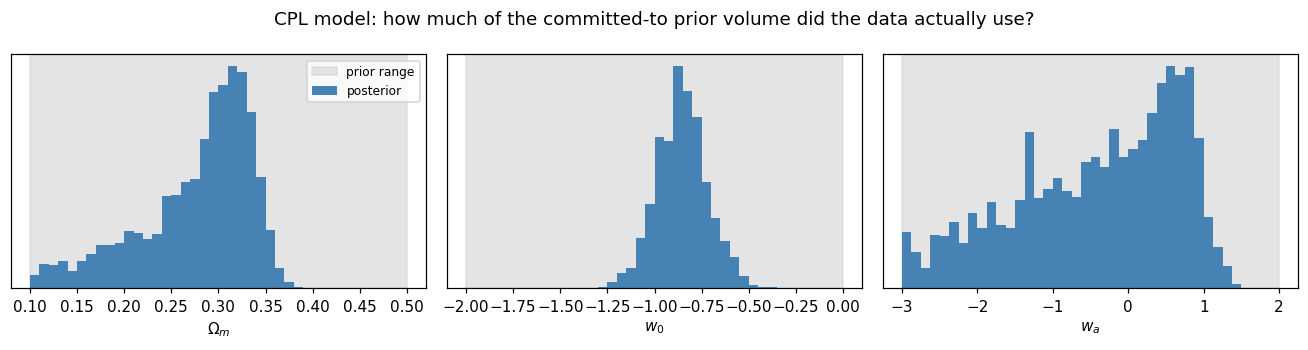

Occam factor Z/Lmax (CPL):  0.0040
Occam factor Z/Lmax (LCDM): 0.0691

(Smaller = more of the committed prior volume was 'wasted' relative to what the data needed.)


In [ ]:
prior_ranges = {"Om": (0.1, 0.5), "w0": (-2.0, 0.0), "wa": (-3.0, 2.0)}
labels = [r"$\Omega_m$", r"$w_0$", r"$w_a$"]
keys = ["Om", "w0", "wa"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, key, lab, i in zip(axes, keys, labels, range(3)):
    lo, hi = prior_ranges[key]
    ax.axvspan(lo, hi, color="lightgray", alpha=0.6, label="prior range")
    ax.hist(samples_CPL[:, i], bins=40, range=(lo, hi), density=True, color="steelblue", label="posterior")
    ax.set_xlabel(lab)
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle(r"CPL model: how much of the committed-to prior volume did the data actually use?")
plt.tight_layout()
plt.show()

occam_factor_CPL  = np.exp(logZ_CPL - lnLmax_CPL)
occam_factor_LCDM = np.exp(logZ_LCDM - lnLmax_LCDM)
print(f"Occam factor Z/Lmax (CPL):  {occam_factor_CPL:.4f}")
print(f"Occam factor Z/Lmax (LCDM): {occam_factor_LCDM:.4f}")
print("\n(Smaller = more of the committed prior volume was 'wasted' relative to what the data needed.)")

Look at the $w_a$ panel especially: the posterior is almost as wide as the entire prior we
allowed. The data barely constrained it at all — the model paid the full "entry price" of an extra
free parameter without buying much sharper predictions in return. That is Occam's razor, made
quantitative.


## Part 10 — Your turn: add a third model

So far we've only compared the two extremes: fully constant ($\Lambda$CDM, $k=1$) versus fully
evolving (CPL, $k=3$). Cosmologists often also consider an intermediate model:

- **Model $M_{0.5}$ ($w$CDM):** dark energy has a constant equation of state $w \neq -1$, but it
  does **not** evolve with redshift. Two free parameters: $\Omega_m$ and $w$. (Set $w_a=0$ in the
  CPL formula — $w$CDM is $\Lambda$CDM's freedom to move off $w=-1$, without the freedom to evolve.)

### Exercise 4

Complete the log-likelihood `loglike_wCDM`, following the exact same pattern as `loglike_LCDM` and
`loglike_CPL` above (they differ only in which parameters are free and which are pinned).

### Exercise 5

Complete the prior transform `ptform_wCDM`. Use the same prior ranges already used for `Om` and
`w0` in the CPL model above, so the models stay comparable.

**Hint for both:** copy the structure of the CPL functions, then simply drop `wa` from the
parameter vector and hard-code `wa=0.0` inside the model evaluation.


In [ ]:
def loglike_wCDM(theta):
    # Log-likelihood for constant-w dark energy (Om, w free; wa fixed at 0).
    # TODO (Exercise 4): unpack theta into Om, w and compute -0.5*chi^2 exactly like loglike_CPL,
    # but calling DV_over_rd(z_eff, Om, w, 0.0)
    Om, w = theta
    model = DV_over_rd(z_eff, Om, w, 0.0) # wa fixed at 0
    return -0.5 * np.sum(((data_obs - model) / sigma)**2)

def ptform_wCDM(u):
    # Prior transform: Om ~ U(0.1, 0.5), w ~ U(-2, 0).
    # TODO (Exercise 5): map the 2-element unit cube u onto (Om, w) using the same ranges
    # as ptform_CPL used for its first two parameters
    Om = 0.1 + 0.4 * u[0]
    w = -2.0 + 2.0 * u[1]
    return np.array([Om, w])


# --- once both functions above are implemented, this cell will run the analysis ---
print("Running nested sampling for wCDM (2 parameters)...")
sampler_wCDM = dynesty.NestedSampler(loglike_wCDM, ptform_wCDM, ndim=2, nlive=250)
sampler_wCDM.run_nested(print_progress=False)
res_wCDM = sampler_wCDM.results
logZ_wCDM, logZerr_wCDM = res_wCDM.logz[-1], res_wCDM.logzerr[-1]
print(f"  log Z (wCDM) = {logZ_wCDM:.3f} +/- {logZerr_wCDM:.3f}")

samples_wCDM = resample_equal(res_wCDM.samples, np.exp(res_wCDM.logwt - res_wCDM.logz[-1]))
opt_wCDM = optimize.minimize(lambda th: -loglike_wCDM(th), x0=[0.3, -1.0], bounds=[(0.1, 0.5), (-2, 0)])
lnLmax_wCDM = -opt_wCDM.fun

Running nested sampling for wCDM (2 parameters)...
  log Z (wCDM) = -6.562 +/- 0.189


### Exercise 6 — the full results table

Fill in the missing pieces to build a single results table across all **three** models, with each
model's Bayes factor *relative to $\Lambda$CDM*, and its Jeffreys'-scale interpretation using the
`interpret_bayes_factor` helper from Part 6.

**Hints:**
- $k_{w\mathrm{CDM}} = 2$
- $\mathrm{AIC} = 2k - 2\ln\mathcal L_{\max}$, $\mathrm{BIC} = k\ln n - 2\ln\mathcal L_{\max}$ (same
  formulas as Part 8, just plug in the $w$CDM numbers)
- $\ln B(\text{model vs LCDM}) = \ln Z_{\text{model}} - \ln Z_{\rm LCDM}$


In [ ]:
k_wCDM = 2            # TODO: how many free parameters does wCDM have?
AIC_wCDM = 2*k_wCDM - 2*lnLmax_wCDM
BIC_wCDM = k_wCDM*np.log(n) - 2*lnLmax_wCDM
lnB_wCDM_vs_LCDM = logZ_wCDM - logZ_LCDM

# --- do not edit below; this will print your table once the four lines above are filled in ---
rows = [
    ("LCDM (k=1)", k_LCDM, logZ_LCDM, AIC_LCDM, BIC_LCDM, 0.0),
    ("wCDM (k=2)", k_wCDM, logZ_wCDM, AIC_wCDM, BIC_wCDM, lnB_wCDM_vs_LCDM),
    ("CPL  (k=3)", k_CPL,  logZ_CPL,  AIC_CPL,  BIC_CPL,  lnB_CPL_vs_LCDM),
]
print(f"{'model':12s}{'k':>4s}{'lnZ':>9s}{'AIC':>9s}{'BIC':>9s}{'lnB vs LCDM':>13s}   interpretation")
for name, k, lz, aic, bic, lnb in rows:
    interp = interpret_bayes_factor(lnb).replace("model 1", name.split()[0]).replace("model 0", "LCDM") if lnb is not None else "?"
    print(f"{name:12s}{k!s:>4s}{lz:9.2f}{aic:9.2f}{bic:9.2f}{lnb if lnb is not None else float('nan'):13.2f}   {interp}")

model          k      lnZ      AIC      BIC  lnB vs LCDM   interpretation
LCDM (k=1)     1    -4.82     6.29     6.23         0.00   Inconclusive evidence in favour of neither model (|ln B| = 0.00)
wCDM (k=2)     2    -6.56     7.24     7.13        -1.75   Weak evidence in favour of LCDM (|ln B| = 1.75)
CPL  (k=3)     3    -7.08     9.11     8.95        -2.27   Weak evidence in favour of LCDM (|ln B| = 2.27)


**Discussion prompt (no code needed):** with the default noise level (`frac_err = 0.018`),
does the ranking increase monotonically with model complexity, or does the simplest model win? Now
scroll back up to the mock-data cell in Part 2, change `frac_err` to `0.008` or `0.005` (simulating
much more precise data — think "DESI BAO + CMB + supernovae combined", the way real dark-energy
papers do it), and re-run everything from that cell downward. **Watch the Bayes factor for CPL
flip sign.** This is, in miniature, the actual story of the 2024–2025 DESI results: BAO data *alone*
gives only weak hints of evolving dark energy, but combining datasets sharpens the evidence
considerably.


## Part 11 — Bayesian model averaging

Suppose you don't want to just declare a "winner" and throw the other models away — you want your
best overall prediction for, say, $w(z)$, honestly accounting for the fact that you're not 100%
sure which model is right. **Bayesian Model Averaging (BMA)** does exactly this: predictions from
each model are combined, weighted by each model's **posterior probability**,
$$ p(M_i \mid D) = \frac{Z(M_i)\, p(M_i)}{\sum_j Z(M_j)\, p(M_j)} $$
Assuming equal prior probability for each of our three models, this reduces to normalising the
evidences themselves.


P(LCDM  | data) = 0.782
P(wCDM  | data) = 0.137
P(CPL   | data) = 0.081


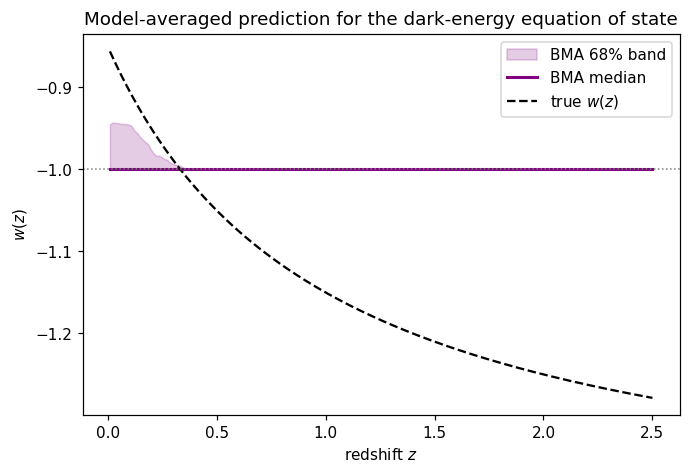

In [ ]:
logZs = np.array([logZ_LCDM, logZ_wCDM, logZ_CPL])
# subtract the max for numerical stability before exponentiating (standard log-sum-exp trick)
weights = np.exp(logZs - logZs.max())
model_probs = weights / weights.sum()

for name, p in zip(["LCDM", "wCDM", "CPL"], model_probs):
    print(f"P({name:5s} | data) = {p:.3f}")

zgrid = np.linspace(0.01, 2.5, 200)

def w_of_z(z, w0, wa):
    return w0 + wa * (z / (1 + z))    # w(a) = w0 + wa(1-a) rewritten in terms of z

# Draw a big pool of posterior (Om, w0, wa) samples for each model, in a common 3-parameter format
draws_LCDM = np.column_stack([samples_LCDM[:, 0], -1.0*np.ones(len(samples_LCDM)), 0.0*np.ones(len(samples_LCDM))])
draws_wCDM = np.column_stack([samples_wCDM[:, 0], samples_wCDM[:, 1], 0.0*np.ones(len(samples_wCDM))])
draws_CPL  = samples_CPL

n_bma = 3000
model_choice = np.random.choice(3, size=n_bma, p=model_probs)   # which model each BMA draw comes from
pools = [draws_LCDM, draws_wCDM, draws_CPL]
bma_curves = np.zeros((n_bma, len(zgrid)))
for i, m in enumerate(model_choice):
    pool = pools[m]
    _, w0, wa = pool[np.random.randint(len(pool))]
    bma_curves[i] = w_of_z(zgrid, w0, wa)

bma_median = np.percentile(bma_curves, 50, axis=0)
bma_lo, bma_hi = np.percentile(bma_curves, 16, axis=0), np.percentile(bma_curves, 84, axis=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.fill_between(zgrid, bma_lo, bma_hi, color="purple", alpha=0.2, label="BMA 68% band")
ax.plot(zgrid, bma_median, color="purple", lw=2, label="BMA median")
ax.plot(zgrid, w_of_z(zgrid, w0_true, wa_true), "k--", label="true $w(z)$")
ax.axhline(-1.0, color="gray", lw=1, ls=":")
ax.set_xlabel("redshift $z$"); ax.set_ylabel("$w(z)$")
ax.set_title("Model-averaged prediction for the dark-energy equation of state")
ax.legend()
plt.show()

Because $\Lambda$CDM (a single point, $w=-1$ always) carries most of the model-averaged
weight in this example, the BMA band hugs $w=-1$ fairly tightly and only widens where the more
flexible models get some vote. This is the honest, hedge-your-bets answer — as opposed to
committing 100% to whichever single model happened to win the Bayes-factor horse race.


## Part 12 — Practical computation of evidences: a cheat sheet

| Method | Idea | Pros | Cons |
|---|---|---|---|
| **Nested sampling** (`MultiNest`, `dynesty`, `UltraNest`, `PolyChord`) | Shrink prior volume, integrate $\mathcal L(X)$ | General purpose; gives $Z$ **and** posterior samples together; handles multimodal posteriors | Can need many likelihood evaluations for high dimensions |
| **Savage–Dickey ratio** | Posterior/prior density ratio at the nested point | Extremely cheap — reuses the bigger model's chain | Only works for nested models at a single point; needs a good density estimate there |
| **Laplace approximation / BIC** | Approximate the posterior as Gaussian around its peak | Instant, no integration | Breaks down for multimodal / prior-dominated / small-sample posteriors |
| **Thermodynamic integration** | Integrate over a sequence of "tempered" posteriors | Very accurate | Expensive — many full MCMC runs |
| **Harmonic mean estimator** | Naive posterior-sample reweighting | Tempting because it reuses ordinary MCMC samples | Numerically unstable — its variance can be formally infinite; best avoided in practice |

**A few habits worth building:**
- Always check `logzerr` (or run twice with different random seeds / live-point counts). If your
  conclusion changes within that Monte Carlo uncertainty, you don't have a robust answer yet.
- Unlike posteriors, **evidences are sensitive to the prior *width***, not just its shape near the
  best fit — quoting your prior ranges is part of reporting an evidence result, and it's good
  practice to check how much your conclusion moves if you double them.
- When you *can* run a Savage–Dickey cross-check (nested models), do it — cheap insurance against
  a nested-sampling bug or an insufficient number of live points.
- More live points and more careful bounding (ellipsoidal vs. random-walk vs. slice proposals in
  `dynesty`) trade runtime for accuracy — start cheap, confirm convergence, then scale up if the
  final answer matters.


## Recap

- **Parameter estimation** (Bayes' theorem within one fixed model) asks what the data say about
  $\theta$; **MCMC** (Metropolis–Hastings, `emcee`) samples that posterior using only ratios of
  $\mathcal L \pi$ — which is exactly why it never needs, and never gives you, $Z$.
- **Bayesian evidence** $Z(M) = \int \mathcal L \pi\, d\theta$ is the probability of the data,
  averaged honestly over the whole prior of a model.
- **Bayes factors** $Z_1/Z_0$ turn evidences into model comparisons; **Jeffreys' scale** gives a
  common language for how convincing a given factor is.
- **Savage–Dickey** is a free shortcut whenever one model nests inside another.
- **Nested sampling** turns the evidence integral into a tractable 1-D quadrature over shrinking
  prior volume, and hands you posterior samples as a bonus.
- **AIC/BIC** are fast, approximate cousins of $-2\ln Z$ — useful, but not a substitute for it.
- **Occam's razor** doesn't need to be imposed by hand in Bayesian model selection — it is already
  built into the evidence integral, via the "Occam factor."
- **Model averaging** lets you report an honest, uncertainty-weighted answer instead of betting
  everything on a single "winning" model.
- Applied to dark energy: this whole toolkit is exactly what lets cosmologists say, quantitatively,
  how convinced (or not) DESI's data should make us that $w \neq -1$.
